# Dataset steup


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

CKPT_DIR = "/content/drive/MyDrive/brisc2025_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print("Checkpoint folder:", CKPT_DIR)

Checkpoint folder: /content/drive/MyDrive/brisc2025_checkpoints


In [ ]:
import glob, os

# Lock ROOT
ROOT = "/content/drive/MyDrive/brisc2025"
print("ROOT set to:", ROOT)

# Check segmentation folders
print("\n--- Segmentation ---")
print("Train images:", len(glob.glob(f"{ROOT}/segmentation_task/train/images/*")))
print("Train masks :", len(glob.glob(f"{ROOT}/segmentation_task/train/masks/*")))
print("Test images :", len(glob.glob(f"{ROOT}/segmentation_task/test/images/*")))
print("Test masks  :", len(glob.glob(f"{ROOT}/segmentation_task/test/masks/*")))

# Check classification folders
print("\n--- Classification ---")
print("Train files:", len(glob.glob(f"{ROOT}/classification_task/train/*/*")))
print("Test files :", len(glob.glob(f"{ROOT}/classification_task/test/*/*")))


ROOT set to: /content/drive/MyDrive/brisc2025

--- Segmentation ---
Train images: 3933
Train masks : 3933
Test images : 860
Test masks  : 860

--- Classification ---
Train files: 5000
Test files : 1000


In [ ]:
import os, glob, random

random.seed(42)

# --- SEGMENTATION full split ---
train_img_dir = f"{ROOT}/segmentation_task/train/images"
train_msk_dir = f"{ROOT}/segmentation_task/train/masks"
test_img_dir  = f"{ROOT}/segmentation_task/test/images"
test_msk_dir  = f"{ROOT}/segmentation_task/test/masks"

def make_seg_pairs(img_dir, msk_dir):
    imgs = sorted(glob.glob(img_dir + "/*"))
    pairs = []
    for ip in imgs:
        base = os.path.splitext(os.path.basename(ip))[0]
        mp = f"{msk_dir}/{base}.png"
        if os.path.exists(mp):
            pairs.append((ip, mp))
    return pairs

seg_train_all = make_seg_pairs(train_img_dir, train_msk_dir)
seg_test_all  = make_seg_pairs(test_img_dir, test_msk_dir)

random.shuffle(seg_train_all)

val_size = int(0.2 * len(seg_train_all))
seg_val_pairs   = seg_train_all[:val_size]
seg_train_pairs = seg_train_all[val_size:]
seg_test_pairs  = seg_test_all

print("SEG full:")
print("Train:", len(seg_train_pairs), "Val:", len(seg_val_pairs), "Test:", len(seg_test_pairs))

# --- CLASSIFICATION full split ---
cls_train_dir = f"{ROOT}/classification_task/train"
cls_test_dir  = f"{ROOT}/classification_task/test"

classes = sorted([d for d in os.listdir(cls_train_dir) if os.path.isdir(os.path.join(cls_train_dir, d))])
class_to_id = {c:i for i,c in enumerate(classes)}

def make_cls_items(base_dir):
    items = []
    for c in classes:
        for p in glob.glob(os.path.join(base_dir, c, "*")):
            items.append((p, class_to_id[c]))
    return items

cls_train_all = make_cls_items(cls_train_dir)
cls_test_items = make_cls_items(cls_test_dir)

random.shuffle(cls_train_all)

val_size_cls = int(0.2 * len(cls_train_all))
cls_val_items   = cls_train_all[:val_size_cls]
cls_train_items = cls_train_all[val_size_cls:]
cls_test_items  = cls_test_items

print("\nCLS full:")
print("Train:", len(cls_train_items), "Val:", len(cls_val_items), "Test:", len(cls_test_items))
print("Classes:", classes)


SEG full:
Train: 3147 Val: 786 Test: 860

CLS full:
Train: 4000 Val: 1000 Test: 1000
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [ ]:
from torch.utils.data import Dataset, DataLoader
import random, os, numpy as np, cv2, torch

IMG_SIZE = 256
BATCH_SEG = 16   # if you get CUDA OOM, change to 8

class SegDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path)[:, :, ::-1]  # RGB
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))      # CHW

        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, 0)          # 1xHxW

        return torch.tensor(img), torch.tensor(mask)

seg_train_loader = DataLoader(SegDataset(seg_train_pairs), batch_size=BATCH_SEG, shuffle=True,  num_workers=2, pin_memory=True)
seg_val_loader   = DataLoader(SegDataset(seg_val_pairs),   batch_size=BATCH_SEG, shuffle=False, num_workers=2, pin_memory=True)
seg_test_loader  = DataLoader(SegDataset(seg_test_pairs),  batch_size=BATCH_SEG, shuffle=False, num_workers=2, pin_memory=True)

print("Seg train batches:", len(seg_train_loader))
print("Seg val batches  :", len(seg_val_loader))
print("Seg test batches :", len(seg_test_loader))

# quick sanity batch
x, y = next(iter(seg_train_loader))
print("x:", x.shape, "y:", y.shape, "mask unique:", torch.unique(y))


Seg train batches: 197
Seg val batches  : 50
Seg test batches : 54
x: torch.Size([16, 3, 256, 256]) y: torch.Size([16, 1, 256, 256]) mask unique: tensor([0., 1.])


#GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
device = "cuda" if torch.cuda.is_available() else "cpu"

CUDA available: True
GPU: Tesla T4


# UNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---- U-Net model ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels*2)
        self.enc3 = DoubleConv(base_channels*2, base_channels*4)
        self.enc4 = DoubleConv(base_channels*4, base_channels*8)

        self.bottleneck = DoubleConv(base_channels*8, base_channels*16)

        self.up4  = nn.ConvTranspose2d(base_channels*16, base_channels*8, 2, 2)
        self.dec4 = DoubleConv(base_channels*16, base_channels*8)

        self.up3  = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, 2)
        self.dec3 = DoubleConv(base_channels*8, base_channels*4)

        self.up2  = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, 2)
        self.dec2 = DoubleConv(base_channels*4, base_channels*2)

        self.up1  = nn.ConvTranspose2d(base_channels*2, base_channels, 2, 2)
        self.dec1 = DoubleConv(base_channels*2, base_channels)

        self.seg_head = nn.Conv2d(base_channels, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b  = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], 1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], 1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], 1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], 1))

        seg_logits = self.seg_head(d1)
        return seg_logits, b

# ---- Loss: BCE + Dice ----
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss_from_logits(logits, target, eps=1e-7):
    probs = torch.sigmoid(logits)
    inter = (probs * target).sum(dim=(1,2,3))
    union = probs.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2*inter + eps) / (union + eps)
    return 1 - dice.mean()

def seg_loss_fn(logits, target):
    return bce_loss(logits, target) + dice_loss_from_logits(logits, target)

# ---- Metrics ----
def dice_score_from_logits(logits, target, eps=1e-7):
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + eps) / (union + eps)).mean().item()

def iou_score_from_logits(logits, target, eps=1e-7):
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred*target).sum(dim=(1,2,3))
    return ((inter + eps) / (union + eps)).mean().item()

def pixel_acc_from_logits(logits, target):
    probs = torch.sigmoid(logits)
    pred = (probs > 0.5).float()
    return (pred == target).float().mean().item()

# ---- Model + optimizer ----
model = UNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_seg_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = total_dice = total_iou = total_acc = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits, _ = model(x)
            loss = seg_loss_fn(logits, y)

            if train:
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

        total_loss += loss.item()
        with torch.no_grad():
            total_dice += dice_score_from_logits(logits, y)
            total_iou  += iou_score_from_logits(logits, y)
            total_acc  += pixel_acc_from_logits(logits, y)

    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n, total_acc/n

In [ ]:
# ---- Train baseline U-Net and save BEST by val Dice ----
EPOCHS = 20
best_val_dice = -1.0
best_path = f"{CKPT_DIR}/unet_best.pth"

for ep in range(1, EPOCHS + 1):
    tr = run_seg_epoch(seg_train_loader, train=True)
    va = run_seg_epoch(seg_val_loader, train=False)

    print(f"[UNET] Epoch {ep}/{EPOCHS} | "
          f"TRAIN loss={tr[0]:.4f} dice={tr[1]:.4f} iou={tr[2]:.4f} acc={tr[3]:.4f} | "
          f"VAL loss={va[0]:.4f} dice={va[1]:.4f} iou={va[2]:.4f} acc={va[3]:.4f}")

    if va[1] > best_val_dice:
        best_val_dice = va[1]
        torch.save({"epoch": ep, "model_state": model.state_dict()}, best_path)
        print("Saved new BEST U-Net:", best_path, "val_dice=", round(best_val_dice, 4))

[UNET] Epoch 1/20 | TRAIN loss=1.1971 dice=0.2873 iou=0.2117 acc=0.9544 | VAL loss=1.0377 dice=0.1419 iou=0.1092 acc=0.9855
Saved new BEST U-Net: /content/drive/MyDrive/brisc2025_checkpoints/unet_best.pth val_dice= 0.1419
[UNET] Epoch 2/20 | TRAIN loss=0.7218 dice=0.5158 iou=0.4060 acc=0.9845 | VAL loss=0.5600 dice=0.5761 iou=0.4626 acc=0.9864
Saved new BEST U-Net: /content/drive/MyDrive/brisc2025_checkpoints/unet_best.pth val_dice= 0.5761
[UNET] Epoch 3/20 | TRAIN loss=0.4924 dice=0.6019 iou=0.4979 acc=0.9889 | VAL loss=0.4850 dice=0.5998 iou=0.4951 acc=0.9877
Saved new BEST U-Net: /content/drive/MyDrive/brisc2025_checkpoints/unet_best.pth val_dice= 0.5998
[UNET] Epoch 4/20 | TRAIN loss=0.4196 dice=0.6490 iou=0.5500 acc=0.9904 | VAL loss=0.3822 dice=0.6785 iou=0.5772 acc=0.9906
Saved new BEST U-Net: /content/drive/MyDrive/brisc2025_checkpoints/unet_best.pth val_dice= 0.6785
[UNET] Epoch 5/20 | TRAIN loss=0.3804 dice=0.6797 iou=0.5823 acc=0.9911 | VAL loss=0.3506 dice=0.7071 iou=0.5981

In [ ]:
import torch

# Load BEST checkpoint saved during training
ckpt = torch.load(f"{CKPT_DIR}/unet_best.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
print("Loaded BEST U-Net from epoch:", ckpt["epoch"])

# Evaluate on TEST
test_loss, test_dice, test_iou, test_acc = run_seg_epoch(seg_test_loader, train=False)
print(f"[UNET TEST] loss={test_loss:.4f} dice={test_dice:.4f} iou={test_iou:.4f} acc={test_acc:.4f}")


Loaded BEST U-Net from epoch: 18
[UNET TEST] loss=0.2388 dice=0.7974 iou=0.7119 acc=0.9937


# Classifier


In [ ]:
import numpy as np, cv2, torch
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 256
BATCH_CLS = 64

class ClsDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]

        img = cv2.imread(img_path)[:, :, ::-1]
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2,0,1))

        return torch.tensor(img), torch.tensor(label, dtype=torch.long)

cls_train_loader = DataLoader(ClsDataset(cls_train_items), batch_size=BATCH_CLS, shuffle=True,  num_workers=0, pin_memory=True)
cls_val_loader   = DataLoader(ClsDataset(cls_val_items),   batch_size=BATCH_CLS, shuffle=False, num_workers=0, pin_memory=True)
cls_test_loader  = DataLoader(ClsDataset(cls_test_items),  batch_size=BATCH_CLS, shuffle=False, num_workers=0, pin_memory=True)

print("Cls train batches:", len(cls_train_loader))
print("Cls val batches  :", len(cls_val_loader))
print("Cls test batches :", len(cls_test_loader))


Cls train batches: 63
Cls val batches  : 16
Cls test batches : 16


In [ ]:
import torch, torch.nn as nn

model = UNet().to(device)

# Load best U-Net weights
ckpt = torch.load(f"{CKPT_DIR}/unet_best.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
print("Loaded U-Net best epoch:", ckpt["epoch"])

# Freeze everything
for p in model.parameters():
    p.requires_grad = False

NUM_CLASSES = len(classes)
print("Classes:", classes)

class EncoderClassifier(nn.Module):
    def __init__(self, unet, num_classes):
        super().__init__()
        self.unet = unet
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        _, b = self.unet(x)
        feat = self.gap(b).squeeze(-1).squeeze(-1)
        return self.fc(feat)

clf = EncoderClassifier(model, NUM_CLASSES).to(device)
print("Classifier ready on:", next(clf.parameters()).device)


Loaded U-Net best epoch: 18
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Classifier ready on: cuda:0


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.nn as nn
import torch

cls_loss_fn = nn.CrossEntropyLoss()
opt_cls = torch.optim.Adam(clf.parameters(), lr=1e-3)

def run_cls_epoch(loader, train=True):
    clf.train() if train else clf.eval()

    total_loss = 0.0
    all_y, all_p = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = clf(x)
            loss = cls_loss_fn(logits, y)

            if train:
                opt_cls.zero_grad(set_to_none=True)
                loss.backward()
                opt_cls.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_y.extend(y.detach().cpu().numpy().tolist())
        all_p.extend(preds.detach().cpu().numpy().tolist())

    acc = accuracy_score(all_y, all_p)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_y, all_p, average="macro", zero_division=0
    )
    return total_loss / len(loader), acc, prec, rec, f1

# ---- train head-only ----
EPOCHS = 8
best_val_acc = -1.0
best_path = f"{CKPT_DIR}/clf_head_best.pth"

for ep in range(1, EPOCHS + 1):
    tr = run_cls_epoch(cls_train_loader, train=True)
    va = run_cls_epoch(cls_val_loader, train=False)

    print(
        f"[CLS-HEAD] Epoch {ep}/{EPOCHS} | "
        f"TRAIN loss={tr[0]:.4f} acc={tr[1]:.4f} prec={tr[2]:.4f} rec={tr[3]:.4f} f1={tr[4]:.4f} | "
        f"VAL loss={va[0]:.4f} acc={va[1]:.4f} prec={va[2]:.4f} rec={va[3]:.4f} f1={va[4]:.4f}"
    )

    if va[1] > best_val_acc:
        best_val_acc = va[1]
        torch.save(
            {"epoch": ep, "clf_state": clf.state_dict(), "classes": classes},
            best_path
        )
        print("Saved BEST head:", best_path, "val_acc=", round(best_val_acc, 4))


[CLS-HEAD] Epoch 1/8 | TRAIN loss=1.2814 acc=0.3675 prec=0.5124 rec=0.3124 f1=0.2433 | VAL loss=1.2160 acc=0.4750 prec=0.6528 rec=0.4553 f1=0.3858
Saved BEST head: /content/drive/MyDrive/brisc2025_checkpoints/clf_head_best.pth val_acc= 0.475
[CLS-HEAD] Epoch 2/8 | TRAIN loss=1.2098 acc=0.5238 prec=0.6000 rec=0.4883 f1=0.4655 | VAL loss=1.1353 acc=0.5500 prec=0.6825 rec=0.5233 f1=0.5257
Saved BEST head: /content/drive/MyDrive/brisc2025_checkpoints/clf_head_best.pth val_acc= 0.55
[CLS-HEAD] Epoch 3/8 | TRAIN loss=1.1566 acc=0.5463 prec=0.6467 rec=0.5241 f1=0.5170 | VAL loss=1.0947 acc=0.6400 prec=0.6902 rec=0.6281 f1=0.6355
Saved BEST head: /content/drive/MyDrive/brisc2025_checkpoints/clf_head_best.pth val_acc= 0.64
[CLS-HEAD] Epoch 4/8 | TRAIN loss=1.1049 acc=0.5887 prec=0.6707 rec=0.5637 f1=0.5767 | VAL loss=1.0451 acc=0.6800 prec=0.7223 rec=0.6654 f1=0.6793
Saved BEST head: /content/drive/MyDrive/brisc2025_checkpoints/clf_head_best.pth val_acc= 0.68
[CLS-HEAD] Epoch 5/8 | TRAIN loss=1

In [ ]:
# ---- Unfreeze last encoder block for fine-tuning ----
for name, p in model.named_parameters():
    if "enc4" in name or "bottleneck" in name:
        p.requires_grad = True

# Also allow classifier head to train
for p in clf.fc.parameters():
    p.requires_grad = True

# Smaller LR for fine-tuning
opt_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, clf.parameters()),
    lr=1e-4
)

EPOCHS_FT = 10
best_val_acc = -1.0
best_path = f"{CKPT_DIR}/clf_finetune_best.pth"

for ep in range(1, EPOCHS_FT + 1):
    tr = run_cls_epoch(cls_train_loader, train=True)
    va = run_cls_epoch(cls_val_loader, train=False)

    print(
        f"[CLS-FT] Epoch {ep}/{EPOCHS_FT} | "
        f"TRAIN acc={tr[1]:.4f} f1={tr[4]:.4f} | "
        f"VAL acc={va[1]:.4f} f1={va[4]:.4f}"
    )

    if va[1] > best_val_acc:
        best_val_acc = va[1]
        torch.save(
            {"epoch": ep, "clf_state": clf.state_dict(), "classes": classes},
            best_path
        )
        print("Saved BEST fine-tuned classifier:", best_path, "val_acc=", round(best_val_acc, 4))


[CLS-FT] Epoch 1/10 | TRAIN acc=0.7350 f1=0.7318 | VAL acc=0.7300 f1=0.7244
Saved BEST fine-tuned classifier: /content/drive/MyDrive/brisc2025_checkpoints/clf_finetune_best.pth val_acc= 0.73
[CLS-FT] Epoch 2/10 | TRAIN acc=0.8137 f1=0.8132 | VAL acc=0.8350 f1=0.8325
Saved BEST fine-tuned classifier: /content/drive/MyDrive/brisc2025_checkpoints/clf_finetune_best.pth val_acc= 0.835
[CLS-FT] Epoch 3/10 | TRAIN acc=0.8500 f1=0.8510 | VAL acc=0.8900 f1=0.8952
Saved BEST fine-tuned classifier: /content/drive/MyDrive/brisc2025_checkpoints/clf_finetune_best.pth val_acc= 0.89
[CLS-FT] Epoch 4/10 | TRAIN acc=0.8925 f1=0.8920 | VAL acc=0.8900 f1=0.8953
[CLS-FT] Epoch 5/10 | TRAIN acc=0.9012 f1=0.9020 | VAL acc=0.8450 f1=0.8473
[CLS-FT] Epoch 6/10 | TRAIN acc=0.9175 f1=0.9197 | VAL acc=0.8650 f1=0.8710
[CLS-FT] Epoch 7/10 | TRAIN acc=0.9413 f1=0.9420 | VAL acc=0.9100 f1=0.9144
Saved BEST fine-tuned classifier: /content/drive/MyDrive/brisc2025_checkpoints/clf_finetune_best.pth val_acc= 0.91
[CLS-FT

In [ ]:
# Load BEST fine-tuned classifier
ckpt = torch.load(f"{CKPT_DIR}/clf_finetune_best.pth", map_location=device)
clf.load_state_dict(ckpt["clf_state"])
print("Loaded fine-tuned classifier from epoch:", ckpt["epoch"])

# Test evaluation
test_loss, test_acc, test_prec, test_rec, test_f1 = run_cls_epoch(
    cls_test_loader, train=False
)

print(
    f"[CLS TEST] "
    f"acc={test_acc:.4f} prec={test_prec:.4f} "
    f"rec={test_rec:.4f} f1={test_f1:.4f}"
)


Loaded fine-tuned classifier from epoch: 10
[CLS TEST] acc=0.8700 prec=0.8707 rec=0.8897 f1=0.8794


# Attention UNet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


In [ ]:
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels*2)
        self.enc3 = DoubleConv(base_channels*2, base_channels*4)
        self.enc4 = DoubleConv(base_channels*4, base_channels*8)

        self.bottleneck = DoubleConv(base_channels*8, base_channels*16)

        self.up4 = nn.ConvTranspose2d(base_channels*16, base_channels*8, 2, 2)
        self.att4 = AttentionGate(base_channels*8, base_channels*8, base_channels*4)
        self.dec4 = DoubleConv(base_channels*16, base_channels*8)

        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, 2)
        self.att3 = AttentionGate(base_channels*4, base_channels*4, base_channels*2)
        self.dec3 = DoubleConv(base_channels*8, base_channels*4)

        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, 2)
        self.att2 = AttentionGate(base_channels*2, base_channels*2, base_channels)
        self.dec2 = DoubleConv(base_channels*4, base_channels*2)

        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, 2)
        self.att1 = AttentionGate(base_channels, base_channels, base_channels//2)
        self.dec1 = DoubleConv(base_channels*2, base_channels)

        self.seg_head = nn.Conv2d(base_channels, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], 1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], 1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], 1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], 1))

        return self.seg_head(d1)


In [ ]:
# Load baseline U-Net weights
base_ckpt = torch.load(f"{CKPT_DIR}/unet_best.pth", map_location=device)

att_model = AttentionUNet().to(device)
att_model.load_state_dict(base_ckpt["model_state"], strict=False)

print("Attention U-Net initialized from baseline U-Net")


Attention U-Net initialized from baseline U-Net


In [ ]:
opt_att = torch.optim.Adam(att_model.parameters(), lr=1e-4)

def run_att_epoch(loader, train=True):
    att_model.train() if train else att_model.eval()
    total_loss = total_dice = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with torch.set_grad_enabled(train):
            logits = att_model(x)
            loss = seg_loss_fn(logits, y)
            if train:
                opt_att.zero_grad()
                loss.backward()
                opt_att.step()

        total_loss += loss.item()
        total_dice += dice_score_from_logits(logits, y)

    return total_loss/len(loader), total_dice/len(loader)

EPOCHS_ATT = 12
best_dice = -1
best_path = f"{CKPT_DIR}/attention_unet_best.pth"

for ep in range(1, EPOCHS_ATT+1):
    tr = run_att_epoch(seg_train_loader, train=True)
    va = run_att_epoch(seg_val_loader, train=False)

    print(f"[ATT] Epoch {ep}/{EPOCHS_ATT} | "
          f"TRAIN dice={tr[1]:.4f} | VAL dice={va[1]:.4f}")

    if va[1] > best_dice:
        best_dice = va[1]
        torch.save(att_model.state_dict(), best_path)
        print("Saved BEST Attention U-Net, val_dice=", round(best_dice,4))


[ATT] Epoch 1/12 | TRAIN dice=0.8289 | VAL dice=0.8302
Saved BEST Attention U-Net, val_dice= 0.8302
[ATT] Epoch 2/12 | TRAIN dice=0.8457 | VAL dice=0.8340
Saved BEST Attention U-Net, val_dice= 0.834
[ATT] Epoch 3/12 | TRAIN dice=0.8536 | VAL dice=0.8356
Saved BEST Attention U-Net, val_dice= 0.8356
[ATT] Epoch 4/12 | TRAIN dice=0.8604 | VAL dice=0.8391
Saved BEST Attention U-Net, val_dice= 0.8391
[ATT] Epoch 5/12 | TRAIN dice=0.8616 | VAL dice=0.8397
Saved BEST Attention U-Net, val_dice= 0.8397
[ATT] Epoch 6/12 | TRAIN dice=0.8673 | VAL dice=0.8375
[ATT] Epoch 7/12 | TRAIN dice=0.8715 | VAL dice=0.8366
[ATT] Epoch 8/12 | TRAIN dice=0.8728 | VAL dice=0.8383
[ATT] Epoch 9/12 | TRAIN dice=0.8751 | VAL dice=0.8369
[ATT] Epoch 10/12 | TRAIN dice=0.8766 | VAL dice=0.8378
[ATT] Epoch 11/12 | TRAIN dice=0.8806 | VAL dice=0.8420
Saved BEST Attention U-Net, val_dice= 0.842
[ATT] Epoch 12/12 | TRAIN dice=0.8794 | VAL dice=0.8386


In [ ]:
# Load BEST Attention U-Net
att_model.load_state_dict(torch.load(f"{CKPT_DIR}/attention_unet_best.pth", map_location=device))
att_model.eval()
print("Loaded BEST Attention U-Net")

# Test evaluation
def run_att_test(loader):
    total_dice = total_iou = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = att_model(x)
            total_dice += dice_score_from_logits(logits, y)
            total_iou  += iou_score_from_logits(logits, y)
    n = len(loader)
    return total_dice/n, total_iou/n

att_test_dice, att_test_iou = run_att_test(seg_test_loader)

print(f"[ATT TEST] Dice={att_test_dice:.4f} IoU={att_test_iou:.4f}")


Loaded BEST Attention U-Net
[ATT TEST] Dice=0.8304 IoU=0.7585


# Visualizations and result

In [ ]:
import numpy as np

# Baseline U-Net
unet = UNet().to(device)
unet_ckpt = torch.load(f"{CKPT_DIR}/unet_best.pth", map_location=device)
unet.load_state_dict(unet_ckpt["model_state"])
unet.eval()

# Attention U-Net
att = AttentionUNet().to(device)
att.load_state_dict(torch.load(f"{CKPT_DIR}/attention_unet_best.pth", map_location=device))
att.eval()

def normalize_for_display(img):
    x = img.astype(np.float32)
    if x.max() > 1.5:
        x = x / 255.0
    lo = np.percentile(x, 1)
    hi = np.percentile(x, 99)
    x = (x - lo) / (hi - lo + 1e-7)
    x = np.clip(x, 0, 1)
    return x

@torch.no_grad()
def predict_mask(model, img_path, threshold=0.5):
    x, rgb = load_rgb_tensor(img_path)
    x = x.to(device)
    logits = model(x)
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    probs = torch.sigmoid(logits)[0,0].cpu().numpy()
    pred = (probs > threshold).astype(np.float32)
    rgb01 = rgb.astype(np.float32) / 255.0
    return rgb01, pred, probs

IMG_SIZE = 256

def load_rgb_tensor(img_path):
    img = cv2.imread(img_path)[:, :, ::-1]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img_chw = np.transpose(img, (2,0,1))
    x = torch.tensor(img_chw).unsqueeze(0)
    return x, img

def find_seg_mask_from_imgpath(img_path):
    base = os.path.splitext(os.path.basename(img_path))[0] + ".png"

    candidates = [
        f"{ROOT}/segmentation_task/test/masks/{base}",
        f"{ROOT}/segmentation_task/train/masks/{base}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

def make_overlay(rgb_img_float01, mask01, alpha=0.45):
    # rgb_img_float01: HxWx3 in [0,1]
    overlay = rgb_img_float01.copy()
    overlay[:,:,1] = np.clip(overlay[:,:,1] + alpha*mask01, 0, 1)
    return overlay

def load_mask(mask_path):
    if mask_path is None or (not os.path.exists(mask_path)):
        return None
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    m = cv2.resize(m, (IMG_SIZE, IMG_SIZE))
    m = (m > 127).astype(np.float32)
    return m

import os
import matplotlib.pyplot as plt

def show_segmentation_panels(img_path):
    rgb01, pred_unet, _ = predict_mask(unet, img_path)
    _,    pred_att,  _ = predict_mask(att, img_path)

    disp = normalize_for_display(rgb01)

    gt_mask_path = find_seg_mask_from_imgpath(img_path)
    gt = load_mask(gt_mask_path) if gt_mask_path else None

    plt.figure(figsize=(8,4.5))

    # --- Row 1: Original + GT ---
    plt.subplot(2,4,1); plt.title("Original"); plt.imshow(disp); plt.axis("off")

    if gt is not None:
        plt.subplot(2,4,2); plt.title("GT Mask"); plt.imshow(gt, cmap="gray"); plt.axis("off")
        plt.subplot(2,4,3); plt.title("GT Overlay"); plt.imshow(make_overlay(disp, gt)); plt.axis("off")
    else:
        plt.subplot(2,4,2); plt.title("GT Mask: not found"); plt.axis("off")
        plt.subplot(2,4,3); plt.title("GT Overlay: not found"); plt.axis("off")

    plt.subplot(2,4,4); plt.title(" "); plt.axis("off")

    # --- Row 2: UNet + AttUNet ---
    plt.subplot(2,4,5); plt.title("U-Net Pred Mask"); plt.imshow(pred_unet, cmap="gray"); plt.axis("off")
    plt.subplot(2,4,6); plt.title("U-Net Overlay"); plt.imshow(make_overlay(disp, pred_unet)); plt.axis("off")

    plt.subplot(2,4,7); plt.title("Att U-Net Pred Mask"); plt.imshow(pred_att, cmap="gray"); plt.axis("off")
    plt.subplot(2,4,8); plt.title("Att U-Net Overlay"); plt.imshow(make_overlay(disp, pred_att)); plt.axis("off")

    plt.suptitle(os.path.basename(img_path))
    plt.tight_layout()
    plt.show()


Seg test images: 860


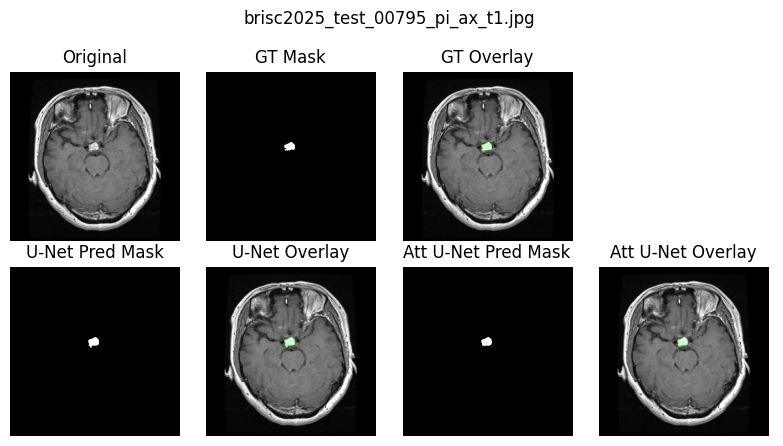

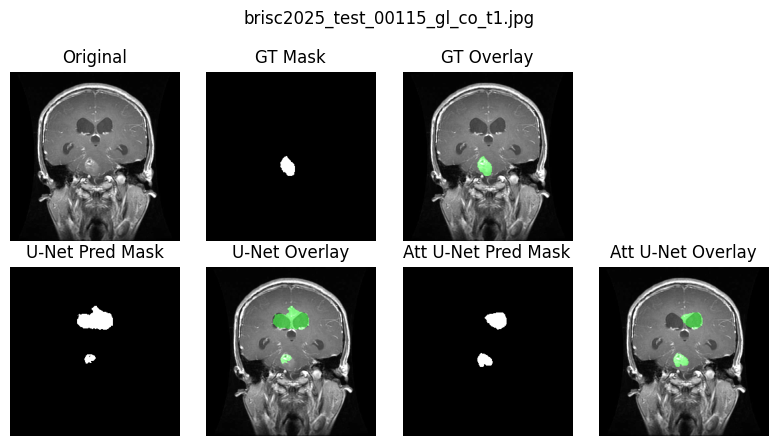

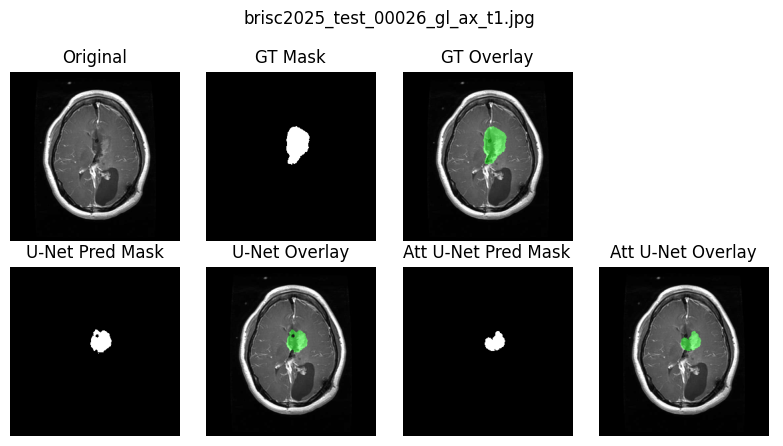

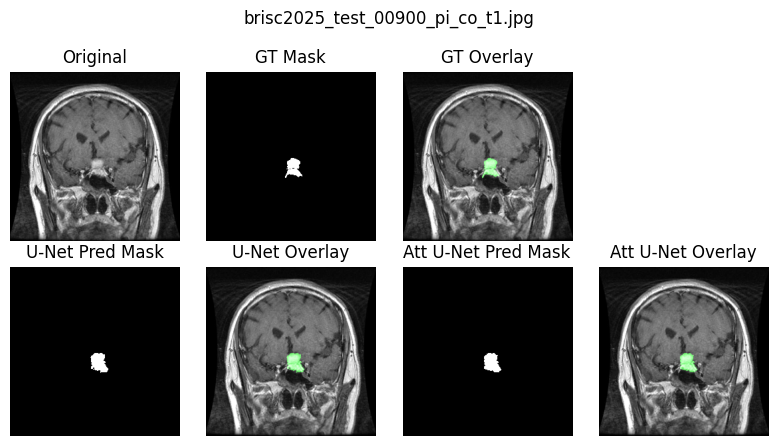

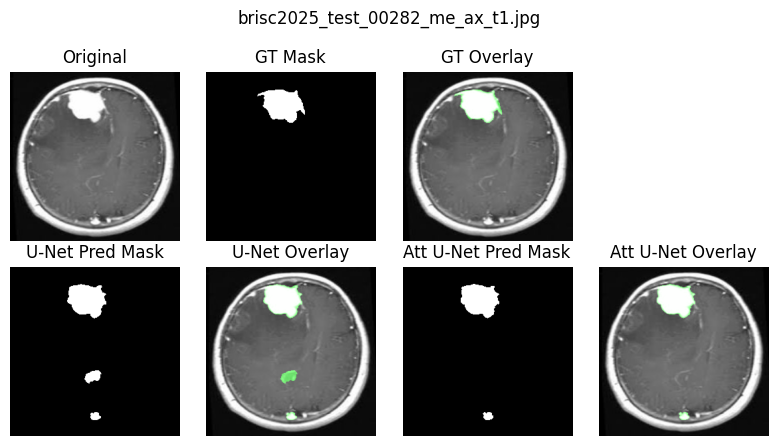

In [ ]:
# pick from segmentation test images
seg_test_imgs = sorted(glob.glob(f"{ROOT}/segmentation_task/test/images/*"))
print("Seg test images:", len(seg_test_imgs))

random.seed(42)
for img_path in random.sample(seg_test_imgs, 5):
    show_segmentation_panels(img_path)


In [ ]:
@torch.no_grad()
def predict_class(img_path):
    x, rgb = load_rgb_tensor(img_path)
    x = x.to(device)
    logits = clf(x)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))
    return rgb, pred_id, probs


Classification test items: 1000
Classes from folder: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

File: brisc2025_test_00660_no_co_t1.jpg
GT: no_tumor | Pred: no_tumor
Probabilities: {'glioma': 0.043346043676137924, 'meningioma': 0.001500925631262362, 'no_tumor': 0.9551283717155457, 'pituitary': 2.472508276696317e-05}


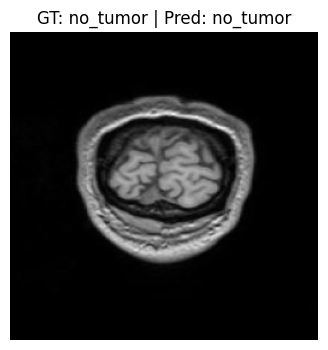


File: brisc2025_test_00048_gl_ax_t1.jpg
GT: glioma | Pred: glioma
Probabilities: {'glioma': 0.9297270178794861, 'meningioma': 0.010786060243844986, 'no_tumor': 0.059295352548360825, 'pituitary': 0.00019150288426317275}


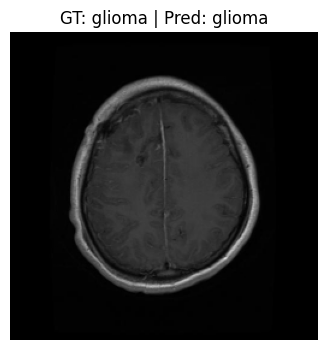


File: brisc2025_test_00031_gl_ax_t1.jpg
GT: glioma | Pred: glioma
Probabilities: {'glioma': 0.9917742609977722, 'meningioma': 0.001198850222863257, 'no_tumor': 0.006903092842549086, 'pituitary': 0.00012375075311865658}


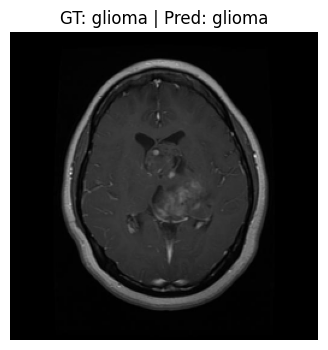


File: brisc2025_test_00764_pi_ax_t1.jpg
GT: pituitary | Pred: pituitary
Probabilities: {'glioma': 7.800181629136205e-05, 'meningioma': 0.00809310469776392, 'no_tumor': 5.0826649385271594e-05, 'pituitary': 0.9917780160903931}


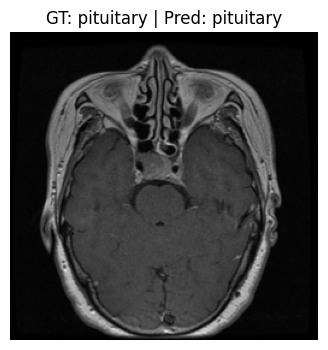


File: brisc2025_test_00332_me_ax_t1.jpg
GT: meningioma | Pred: glioma
Probabilities: {'glioma': 0.51431804895401, 'meningioma': 0.11612290143966675, 'no_tumor': 0.3539111316204071, 'pituitary': 0.0156478863209486}


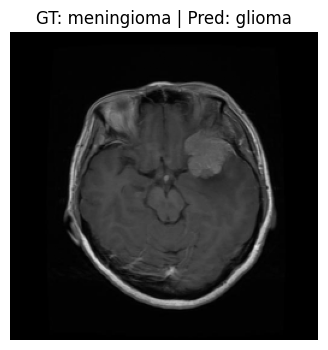

In [ ]:
# Build classification test list
cls_test_dir = f"{ROOT}/classification_task/test"
classes_sorted = sorted([d for d in os.listdir(cls_test_dir) if os.path.isdir(os.path.join(cls_test_dir, d))])
class_to_id = {c:i for i,c in enumerate(classes_sorted)}

cls_test_items = []
for c in classes_sorted:
    for p in glob.glob(os.path.join(cls_test_dir, c, "*")):
        cls_test_items.append((p, class_to_id[c]))

print("Classification test items:", len(cls_test_items))
print("Classes from folder:", classes_sorted)

random.seed(42)
samples = random.sample(cls_test_items, 5)

for img_path, gt in samples:
    rgb, pred_id, probs = predict_class(img_path)
    print("\nFile:", os.path.basename(img_path))
    print("GT:", classes_sorted[gt], "| Pred:", classes[pred_id])
    print("Probabilities:", {classes[i]: float(probs[i]) for i in range(len(classes))})

    plt.figure(figsize=(4,4))
    plt.imshow(rgb[:,:,::-1])
    plt.title(f"GT: {classes_sorted[gt]} | Pred: {classes[pred_id]}")
    plt.axis("off")
    plt.show()


Test Accuracy: 0.894

Classification report:

              precision    recall  f1-score   support

      glioma       0.89      0.93      0.91       254
  meningioma       0.88      0.81      0.84       306
    no_tumor       0.88      0.96      0.91       140
   pituitary       0.92      0.92      0.92       300

    accuracy                           0.89      1000
   macro avg       0.89      0.90      0.90      1000
weighted avg       0.89      0.89      0.89      1000



<Figure size 600x600 with 0 Axes>

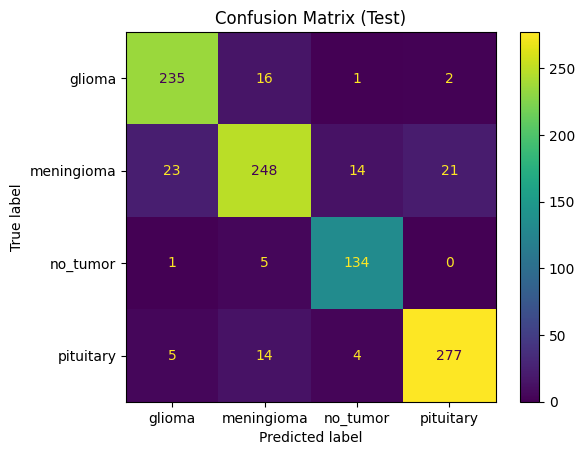

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for img_path, gt in cls_test_items:
    _, pred_id, _ = predict_class(img_path)
    y_true.append(gt)
    y_pred.append(pred_id)

acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", round(acc, 4))
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=classes_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=classes_sorted)

plt.figure(figsize=(6,6))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()


In [ ]:
from google.colab import files
import io
from PIL import Image
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

def pil_to_rgb01(pil_img, size=256):
    img = np.array(pil_img.convert("RGB"))
    img = cv2.resize(img, (size, size)).astype(np.float32) / 255.0
    return img

@torch.no_grad()
def run_on_rgb01(rgb01, thr=0.5):
    # tensor for model
    x = torch.tensor(np.transpose(rgb01, (2,0,1))).unsqueeze(0).to(device)

    # ---- classification ----
    logits_cls = clf(x)
    probs = torch.softmax(logits_cls, dim=1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))

    # ---- segmentation U-Net ----
    logits_u, _ = unet(x)
    prob_u = torch.sigmoid(logits_u)[0,0].cpu().numpy()
    mask_u = (prob_u > thr).astype(np.float32)

    # ---- segmentation Attention ----
    logits_a = att(x)
    prob_a = torch.sigmoid(logits_a)[0,0].cpu().numpy()
    mask_a = (prob_a > thr).astype(np.float32)

    # ---- display ----
    disp = normalize_for_display(rgb01)

    print("Predicted class:", classes[pred_id])
    print("Probabilities:", {classes[i]: float(np.round(probs[i], 4)) for i in range(len(classes))})

    plt.figure(figsize=(14,6))

    plt.subplot(2,3,1); plt.title("Input"); plt.imshow(disp); plt.axis("off")

    plt.subplot(2,3,2); plt.title("U-Net Mask"); plt.imshow(mask_u, cmap="gray"); plt.axis("off")
    plt.subplot(2,3,3); plt.title("U-Net Overlay"); plt.imshow(make_overlay(disp, mask_u)); plt.axis("off")

    plt.subplot(2,3,5); plt.title("Att Mask"); plt.imshow(mask_a, cmap="gray"); plt.axis("off")
    plt.subplot(2,3,6); plt.title("Att Overlay"); plt.imshow(make_overlay(disp, mask_a)); plt.axis("off")

    plt.tight_layout()
    plt.show()

def upload_and_run(thr=0.5):
    uploaded = files.upload()
    for fn in uploaded.keys():
        pil_img = Image.open(io.BytesIO(uploaded[fn]))
        rgb01 = pil_to_rgb01(pil_img, size=IMG_SIZE)
        print("File:", fn)
        run_on_rgb01(rgb01, thr=thr)


Saving brisc2025_test_00858_pi_co_t1.jpg to brisc2025_test_00858_pi_co_t1 (1).jpg
File: brisc2025_test_00858_pi_co_t1 (1).jpg
Predicted class: pituitary
Probabilities: {'glioma': 0.032600000500679016, 'meningioma': 0.015399999916553497, 'no_tumor': 0.0003000000142492354, 'pituitary': 0.95169997215271}


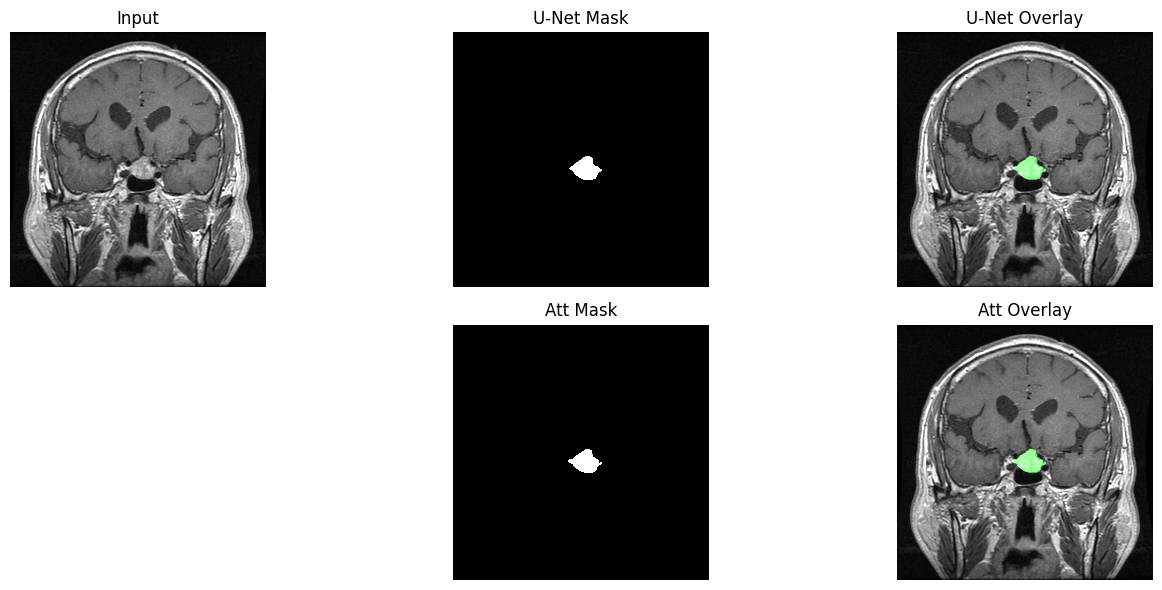

In [ ]:
upload_and_run(thr=0.5)
